In [ ]:
!pip install emulator
!pip install qutip
!pip install distproc

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qutip import *
from scipy.fft import fft, fftfreq
plt.rcParams['figure.dpi'] = 120

In [ ]:
N_chain = 6

J = 1.0
h = 1.0

# Adjusting parameters to meet the user's request:
# J * T1 = 0.25 * pi => T1 = 0.25 * pi / J
# h * T2 = 0.50 * pi => T2 = 0.50 * pi / h
T1 = 0.25 * np.pi / J
T2 = 0.50 * np.pi / h

periods = 40

g_default = 0.05
gamma_default = 0.0

omega_tls = 0.0

print(f"Updated parameters: T1={T1:.4f}, T2={T2:.4f}")
print(f"Check: J*T1/pi = {J*T1/np.pi:.2f}, h*T2/pi = {h*T2/np.pi:.2f}")

Updated parameters: T1=0.7854, T2=1.5708
Check: J*T1/pi = 0.25, h*T2/pi = 0.50


In [ ]:

def make_site_operator(op, site, Ntot):
    """
    Returns: I ⊗ ... ⊗ op ⊗ ... ⊗ I
    Where op is at the specified 'site' index.
    """
    op_list = []
    for i in range(Ntot):
        if i == site:
            op_list.append(op)
        else:
            # Assuming the dimension of the Hilbert space at each site matches the operator's shape
            # For a TLS or Spin-1/2, qeye(2) is used.
            op_list.append(qeye(op.dims[0][0]))
    return tensor(op_list)

In [ ]:
def build_operator_lists(N_chain):
    """
    Builds lists of operators (sx, sy, sz, sm) for each site in the system.
    Total sites Ntot = N_chain + 1 (site 0 is the TLS).
    """
    Ntot = N_chain + 1
    sx_list = []
    sy_list = []
    sz_list = []
    sm_list = []

    for i in range(Ntot):
        sx_list.append(make_site_operator(sigmax(), i, Ntot))
        sy_list.append(make_site_operator(sigmay(), i, Ntot))
        sz_list.append(make_site_operator(sigmaz(), i, Ntot))
        sm_list.append(make_site_operator(destroy(2), i, Ntot))

    return sx_list, sy_list, sz_list, sm_list

In [ ]:
sx_list, sy_list, sz_list, sm_list = build_operator_lists(N_chain)
print(f"Successfully generated operator lists for {N_chain + 1} sites.")

Successfully generated operator lists for 7 sites.


In [ ]:
def build_static_terms(N_chain, sz_list, sx_list, sz_sz_list, omega_tls, h, J, g):
    """
    Constructs the static components of the Hamiltonian.
    Returns a dictionary of terms.
    """
    # 1. TLS term (site 0)
    H_tls = 0.5 * omega_tls * sz_list[0]

    # 2. Interaction between TLS (0) and first chain site (1)
    H_int = g * (sx_list[0] * sx_list[1])

    # 3. ZZ Coupling terms within the chain (site 1 to N_chain)
    H_ZZ = 0
    for i in range(1, N_chain):
        H_ZZ += J * sz_list[i] * sz_list[i+1]

    # 4. Transverse field (X) terms for the chain
    H_X = 0
    for i in range(1, N_chain + 1):
        # Removed the 0.5 factor to ensure a proper pi-pulse rotation
        H_X += h * sx_list[i]

    return {
        "H_tls": H_tls,
        "H_int": H_int,
        "H_ZZ": H_ZZ,
        "H_X": H_X
    }

In [ ]:
def run_floquet(psi0, g, gamma, periods, N_chain, sz_list, sx_list, T1, T2, omega_tls, h, J):
    """
    Performs Floquet evolution in two steps per period.
    Step 1: H1 for duration T1
    Step 2: H2 for duration T2
    """
    # 1. Build Hamiltonian components for the given g
    # Note: sz_sz_list is not used in the current build_static_terms logic, passing None
    terms = build_static_terms(N_chain, sz_list, sx_list, None, omega_tls, h, J, g)

    # Define the two Hamiltonians for the Floquet steps
    # Step 1: Often just the ZZ interaction + TLS/Int
    H1 = terms["H_tls"] + terms["H_int"] + terms["H_ZZ"]
    # Step 2: Often the Transverse field part
    H2 = terms["H_X"]

    # 2. Setup dissipation (collapse operators)
    c_ops = []
    if gamma > 0:
        for sm in sm_list:
            c_ops.append(np.sqrt(gamma) * sm)

    # 3. Evolution loop
    current_state = psi0
    all_states = [psi0]
    all_times = [0.0]

    dt = 0.05 # Time step for recording data within intervals

    for p in range(periods):
        t_start = p * (T1 + T2)

        # Step 1 Evolution
        tlist1 = np.linspace(0, T1, max(2, int(T1/dt)))
        res1 = mesolve(H1, current_state, tlist1, c_ops=c_ops)

        # Step 2 Evolution
        current_state = res1.states[-1]
        tlist2 = np.linspace(0, T2, max(2, int(T2/dt)))
        res2 = mesolve(H2, current_state, tlist2, c_ops=c_ops)

        # Update state and record (excluding the first point of res to avoid overlap)
        current_state = res2.states[-1]

        # Append results
        for i in range(1, len(res1.states)):
            all_states.append(res1.states[i])
            all_times.append(t_start + tlist1[i])

        for i in range(1, len(res2.states)):
            all_states.append(res2.states[i])
            all_times.append(t_start + T1 + tlist2[i])

    return all_states, np.array(all_times)

In [ ]:
# 1. Initialize the state: TLS in |1>, rest of the chain in |0>
# Total sites = N_chain + 1. Index 0 is the TLS.
initial_ops = [basis(2, 1)] + [basis(2, 0)] * N_chain
psi0 = tensor(initial_ops)

# 2. Run the simulation
print(f"Starting Floquet simulation for {periods} periods...")
states, times = run_floquet(
    psi0=psi0,
    g=g_default,
    gamma=gamma_default,
    periods=periods,
    N_chain=N_chain,
    sz_list=sz_list,
    sx_list=sx_list,
    T1=T1,
    T2=T2,
    omega_tls=omega_tls,
    h=h,
    J=J
)

# 3. Calculate expectation values for the TLS (site 0) sz
sz_tls_expt = expect(sz_list[0], states)

print("Simulation complete.")
print(f"Generated {len(times)} time points.")

Starting Floquet simulation for 40 periods...
Simulation complete.
Generated 1761 time points.


In [ ]:
def measure_magnetization(states, sz_list):
    """
    Calculates expectation values for specific sites:
    - TLS (site 0)
    - Edge (site 1)
    - Bulk (approx. N_chain / 2)
    """
    N_tot = len(sz_list)
    bulk_index = N_tot // 2

    tls_expt = expect(sz_list[0], states)
    edge_expt = expect(sz_list[1], states)
    bulk_expt = expect(sz_list[bulk_index], states)

    return {
        "tls": tls_expt,
        "edge": edge_expt,
        "bulk": bulk_expt
    }

# Example usage with the current 'states' and 'sz_list'
mag_data = measure_magnetization(states, sz_list)
print("Magnetization measurement complete.")

Magnetization measurement complete.


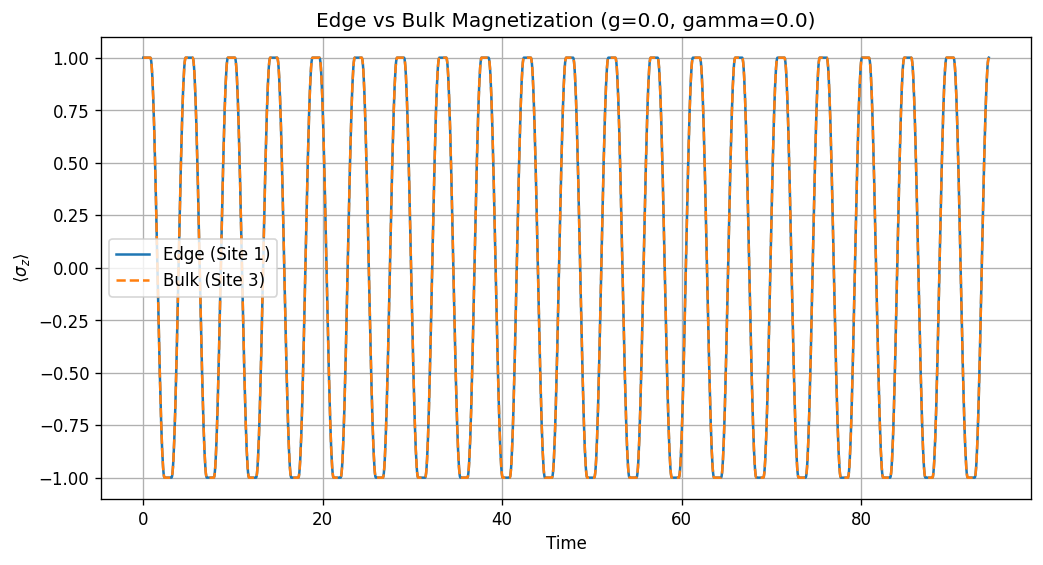

In [ ]:
# 1. Run simulation with g=0 and gamma=0
g_zero = 0.0
gamma_zero = 0.0

states_zero, times_zero = run_floquet(
    psi0=psi0,
    g=g_zero,
    gamma=gamma_zero,
    periods=periods,
    N_chain=N_chain,
    sz_list=sz_list,
    sx_list=sx_list,
    T1=T1,
    T2=T2,
    omega_tls=omega_tls,
    h=h,
    J=J
)

# 2. Measure magnetization
mag_data_zero = measure_magnetization(states_zero, sz_list)

# 3. Plot Edge vs Bulk
plt.figure(figsize=(10, 5))
plt.plot(times_zero, mag_data_zero['edge'], label='Edge (Site 1)', linestyle='-')
plt.plot(times_zero, mag_data_zero['bulk'], label=f'Bulk (Site {len(sz_list)//2})', linestyle='--')

plt.xlabel('Time')
plt.ylabel(r'$\langle\sigma_z\rangle$')
plt.title(f'Edge vs Bulk Magnetization (g={g_zero}, gamma={gamma_zero})')
plt.legend()
plt.grid(True)
plt.ylim(-1.1, 1.1)
plt.show()

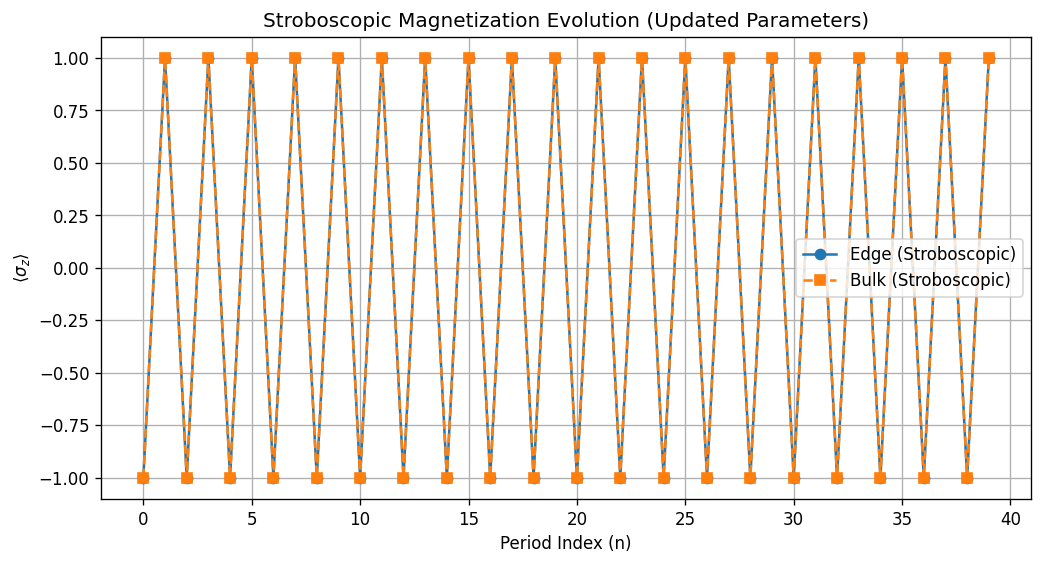

In [ ]:
# 1. Prepare the Unitary Propagators with updated T1, T2
terms = build_static_terms(N_chain, sz_list, sx_list, None, omega_tls, h, J, g_zero)
H1 = terms["H_tls"] + terms["H_int"] + terms["H_ZZ"]
H2 = terms["H_X"]

U1 = (-1j * H1 * T1).expm()
U2 = (-1j * H2 * T2).expm()

# 2. Discrete evolution loop
psi = psi0
edge_signal = []
bulk_signal = []
N_bulk = (N_chain + 1) // 2

for n in range(periods):
    # Apply the two-step Floquet operator
    psi = U2 * U1 * psi

    # Measure expectation values
    edge_signal.append(expect(sz_list[1], psi))
    bulk_signal.append(expect(sz_list[N_bulk], psi))

# 3. Plot the stroboscopic signals
plt.figure(figsize=(10, 5))
plt.plot(range(periods), edge_signal, 'o-', label='Edge (Stroboscopic)')
plt.plot(range(periods), bulk_signal, 's--', label='Bulk (Stroboscopic)')
plt.xlabel('Period Index (n)')
plt.ylabel(r'$\langle\sigma_z\rangle$')
plt.title('Stroboscopic Magnetization Evolution (Updated Parameters)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def get_subharmonic_strength(T1_val, T2_val, n_periods=40, method='normalized_fft'):
    # Re-build Hamiltonians for this specific T1, T2
    terms = build_static_terms(N_chain, sz_list, sx_list, None, omega_tls, h, J, 0.0)
    H1 = terms["H_tls"] + terms["H_int"] + terms["H_ZZ"]
    H2 = terms["H_X"]

    U1 = (-1j * H1 * T1_val).expm()
    U2 = (-1j * H2 * T2_val).expm()
    U_floquet = U2 * U1

    # Evolution (Stroboscopic)
    psi = psi0
    signal = []
    for _ in range(n_periods):
        psi = U_floquet * psi
        signal.append(expect(sz_list[1], psi))

    signal = np.array(signal)

    if method == 'normalized_fft':
        # 1. Subtract DC component
        signal_zero_mean = signal - np.mean(signal)
        # 2. FFT
        yf = np.fft.fft(signal_zero_mean)
        psd = np.abs(yf)**2
        # 3. Strength at omega = Omega/2 (index n/2)
        # We normalize by total power to see 'purity'
        total_power = np.sum(psd)
        if total_power < 1e-12: return 0.0
        return psd[n_periods // 2] / total_power

    elif method == 'staggered':
        # m_n * (-1)^n component
        signal_zero_mean = signal - np.mean(signal)
        stagger = np.array([(-1)**n for n in range(n_periods)])
        return np.abs(np.mean(signal_zero_mean * stagger))

In [ ]:
# Re-running the 2D scan with the Normalized FFT method
resolution = 15
periods_scan = 40
JT1_norm = np.linspace(0.15, 0.35, resolution)
hT2_norm = np.linspace(0.35, 0.65, resolution)

phase_map_normalized = np.zeros((resolution, resolution))

print(f"Starting Cleaned 2D scan ({resolution}x{resolution})...")
for i, hT2_val in enumerate(hT2_norm):
    for j, JT1_val in enumerate(JT1_norm):
        actual_T1 = (JT1_val * np.pi) / J
        actual_T2 = (hT2_val * np.pi) / h

        # Using the normalized FFT method for the order parameter
        phase_map_normalized[i, j] = get_subharmonic_strength(actual_T1, actual_T2, n_periods=periods_scan, method='normalized_fft')

print("Scan complete.")

Starting Cleaned 2D scan (15x15)...
Scan complete.


<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4576/3992583915.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Floquet $\pi$-Phase Diagram (Normalized Order Parameter)')


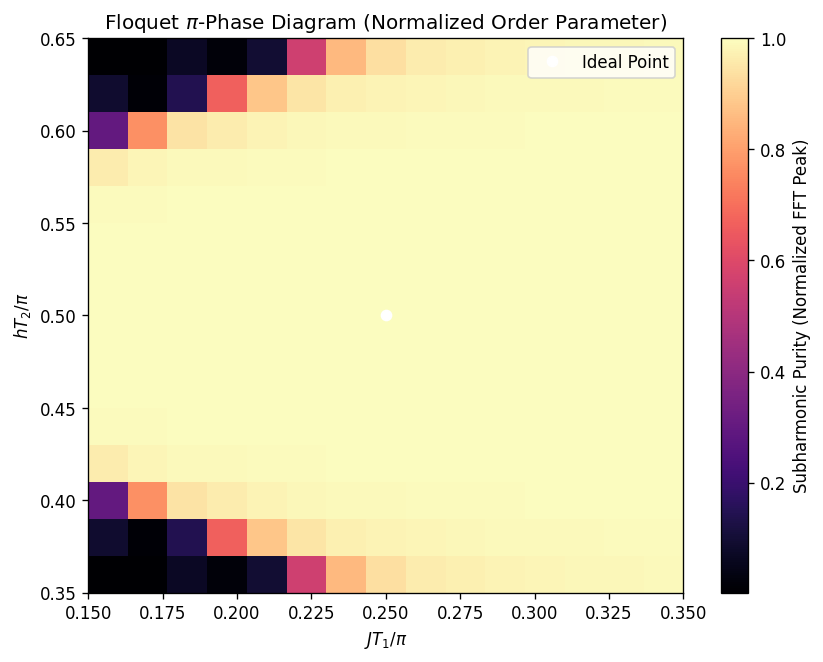

In [ ]:
# Visualize the CLEANED Phase Diagram
plt.figure(figsize=(8, 6))
plt.imshow(
    phase_map_normalized,
    origin='lower',
    aspect='auto',
    extent=[JT1_norm[0], JT1_norm[-1], hT2_norm[0], hT2_norm[-1]],
    cmap='magma'
)

plt.colorbar(label='Subharmonic Purity (Normalized FFT Peak)')
plt.xlabel(r'$JT_1 / \pi$')
plt.ylabel(r'$hT_2 / \pi$')
plt.title('Floquet $\pi$-Phase Diagram (Normalized Order Parameter)')

# Mark the ideal theoretical point
plt.plot(0.25, 0.50, 'wo', label='Ideal Point')
plt.legend()
plt.show()

### Diagnostic: Time-Trace at the Ideal Point
We will now use an edge-flipped initial state: $|0_{tls}, 1_{edge}, 0_{bulk}...\rangle$ and observe the stroboscopic evolution of the edge magnetization at $JT_1/\pi=0.25$ and $hT_2/\pi=0.5$.

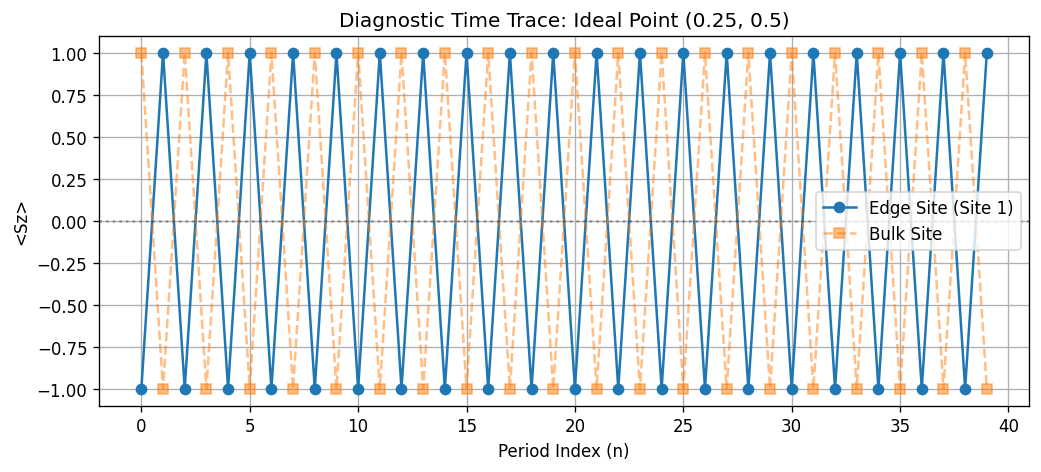

In [ ]:
# 1. New Initial State: Edge flipped (site 1), others in |0>
new_initial_ops = [basis(2, 0), basis(2, 1)] + [basis(2, 0)] * (N_chain - 1)
psi0_edge = tensor(new_initial_ops)

# 2. Parameters for the 'Ideal Point'
JT1_target = 0.25
hT2_target = 0.50
T1_diag = (JT1_target * np.pi) / J
T2_diag = (hT2_target * np.pi) / h

# 3. Build Propagators (Ensuring Hermiticity)
terms_diag = build_static_terms(N_chain, sz_list, sx_list, None, omega_tls, h, J, 0.0)
# Corrected: H1 and H2 must be summed fully before multiplication by -1j*T
H1 = terms_diag['H_tls'] + terms_diag['H_int'] + terms_diag['H_ZZ']
H2 = terms_diag['H_X']

U1_diag = (-1j * H1 * T1_diag).expm()
U2_diag = (-1j * H2 * T2_diag).expm()
U_floquet_diag = U2_diag * U1_diag

# 4. Evolution
n_periods_diag = 40
psi = psi0_edge
edge_trace = []
bulk_trace = []

for n in range(n_periods_diag):
    edge_trace.append(expect(sz_list[1], psi))
    bulk_trace.append(expect(sz_list[N_chain//2 + 1], psi))
    psi = U_floquet_diag * psi

# 5. Plotting
plt.figure(figsize=(10, 4))
plt.plot(range(n_periods_diag), edge_trace, 'o-', label='Edge Site (Site 1)')
plt.plot(range(n_periods_diag), bulk_trace, 's--', alpha=0.5, label='Bulk Site')
plt.axhline(0, color='k', linestyle=':', alpha=0.3)
plt.ylim(-1.1, 1.1)
plt.xlabel('Period Index (n)')
plt.ylabel('<Sz>')
plt.title(f'Diagnostic Time Trace: Ideal Point ({JT1_target}, {hT2_target})')
plt.legend()
plt.grid(True)
plt.show()

### Scanning TLS-Edge Coupling ($g$)
We investigate how the TLS synchronizes with the Discrete Time Crystal (DTC) edge mode as we vary the coupling strength $g$.

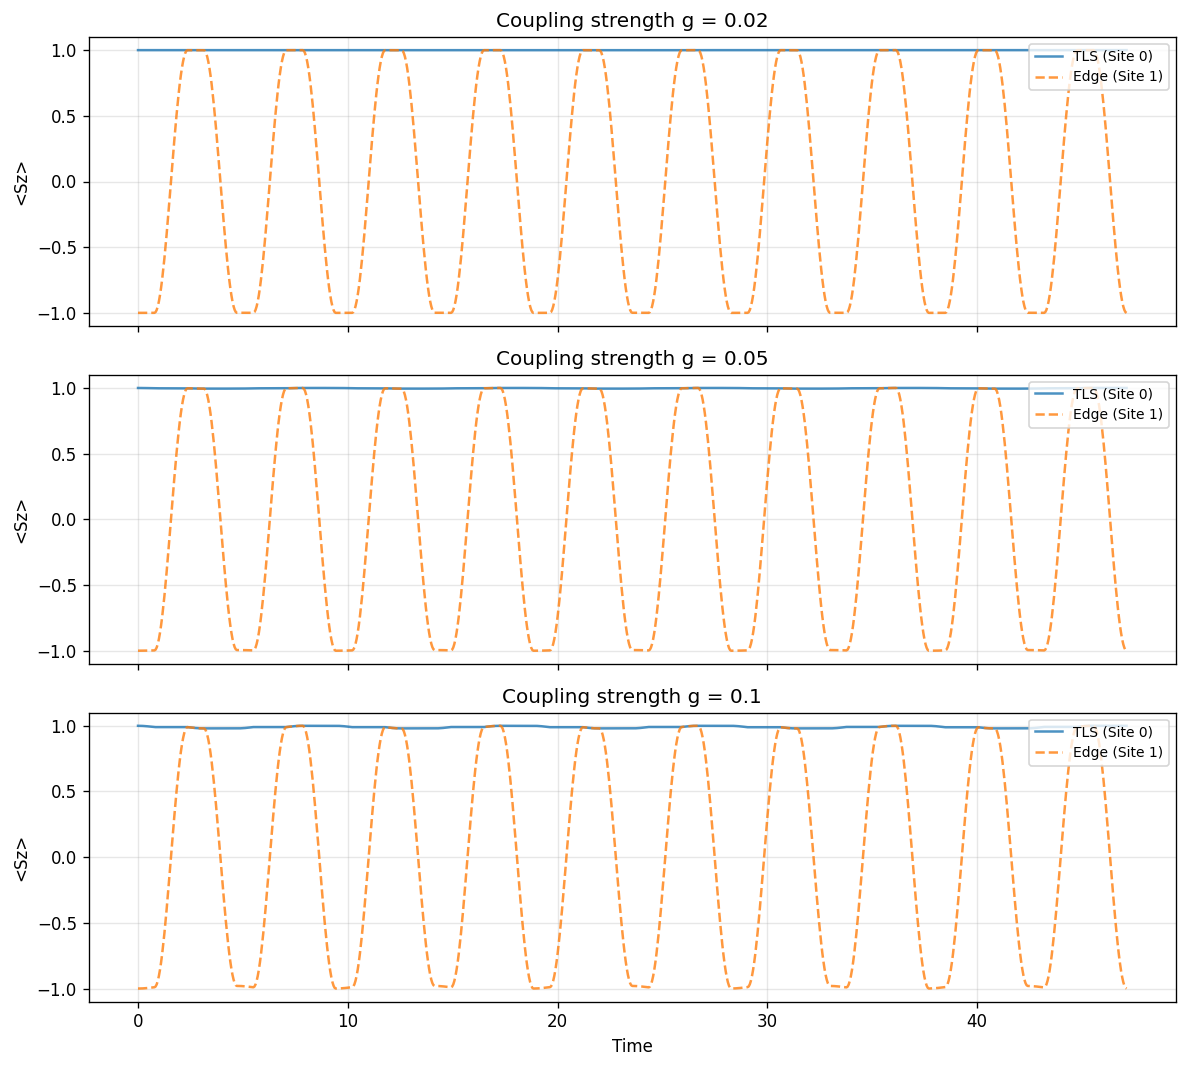

In [ ]:
g_list = [0.02, 0.05, 0.1]
fig, axes = plt.subplots(len(g_list), 1, figsize=(10, 3 * len(g_list)), sharex=True)

# Reuse parameters from the Ideal Point
# Initial state: Edge flipped, TLS in |0>
psi0_sync = tensor([basis(2, 0), basis(2, 1)] + [basis(2, 0)] * (N_chain - 1))

for idx, g_val in enumerate(g_list):
    # Run Floquet simulation for this g
    # Using mesolve method from run_floquet to see full time evolution (micro-motion)
    states_g, times_g = run_floquet(
        psi0=psi0_sync,
        g=g_val,
        gamma=0.0,
        periods=20, # Reduced periods for clarity in micro-motion
        N_chain=N_chain,
        sz_list=sz_list,
        sx_list=sx_list,
        T1=T1_diag,
        T2=T2_diag,
        omega_tls=0.0,
        h=h,
        J=J
    )

    # Calculate expectations
    tls_sz = expect(sz_list[0], states_g)
    edge_sz = expect(sz_list[1], states_g)

    # Plotting
    ax = axes[idx]
    ax.plot(times_g, tls_sz, label='TLS (Site 0)', alpha=0.8)
    ax.plot(times_g, edge_sz, label='Edge (Site 1)', linestyle='--', alpha=0.8)
    ax.set_title(f'Coupling strength g = {g_val}')
    ax.set_ylabel('<Sz>')
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.1, 1.1)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

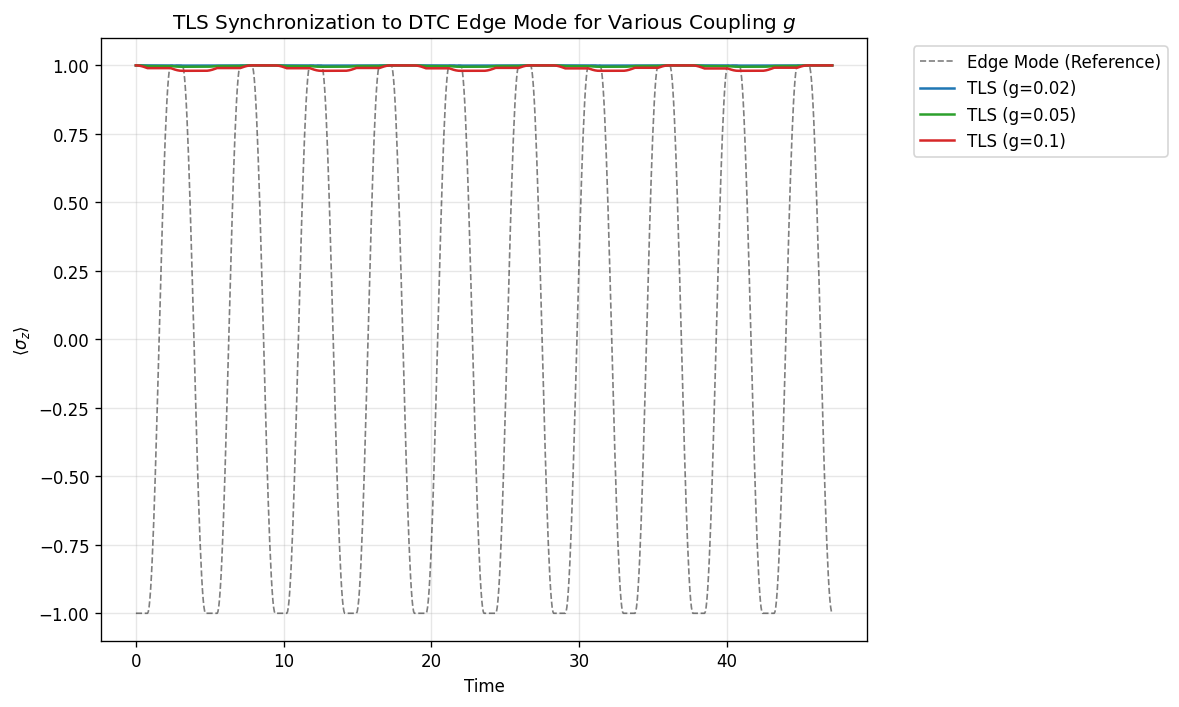

In [ ]:
import matplotlib.pyplot as plt

# Parameters and Initial State
g_list = [0.02, 0.05, 0.1]
colors = ['tab:blue', 'tab:green', 'tab:red']
psi0_sync = tensor([basis(2, 0), basis(2, 1)] + [basis(2, 0)] * (N_chain - 1))

plt.figure(figsize=(10, 6))

# First, run once to get the baseline Edge signal (it is nearly the same for all small g)
states_ref, times_ref = run_floquet(
    psi0=psi0_sync, g=0.0, gamma=0.0, periods=20,
    N_chain=N_chain, sz_list=sz_list, sx_list=sx_list,
    T1=T1_diag, T2=T2_diag, omega_tls=0.0, h=h, J=J
)
edge_sz_ref = expect(sz_list[1], states_ref)
plt.plot(times_ref, edge_sz_ref, 'k--', label='Edge Mode (Reference)', alpha=0.5, linewidth=1)

# Loop through g values and plot TLS response on the same axes
for idx, g_val in enumerate(g_list):
    states_g, times_g = run_floquet(
        psi0=psi0_sync, g=g_val, gamma=0.0, periods=20,
        N_chain=N_chain, sz_list=sz_list, sx_list=sx_list,
        T1=T1_diag, T2=T2_diag, omega_tls=0.0, h=h, J=J
    )
    tls_sz = expect(sz_list[0], states_g)
    plt.plot(times_g, tls_sz, color=colors[idx], label=f'TLS (g={g_val})', linewidth=1.5)

plt.title('TLS Synchronization to DTC Edge Mode for Various Coupling $g$')
plt.xlabel('Time')
plt.ylabel(r'$\langle\sigma_z\rangle$')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

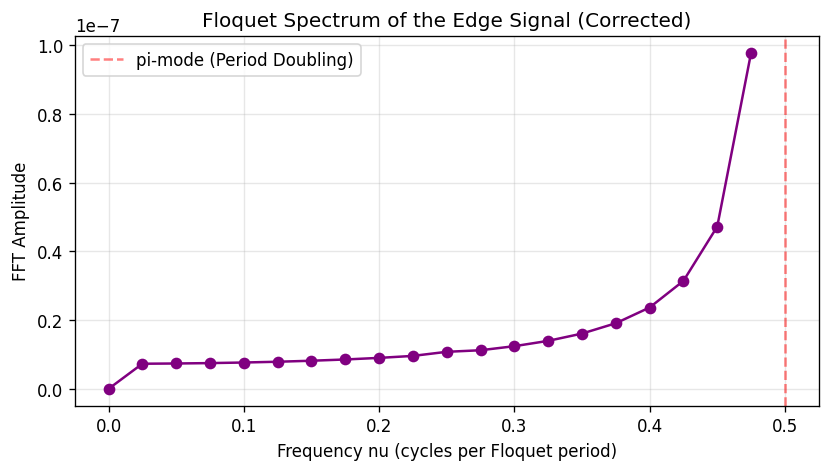

In [ ]:
from scipy.fft import fft, fftfreq

# 1. 提取频闪观测数据 (Stroboscopic Extraction)
T_total = T1 + T2
m_n = []

# 只提取每个周期末尾的那个点 (n*T)
for p in range(periods):
    target_t = p * T_total
    # 找到 times_zero 中最接近目标时间的索引
    idx = np.argmin(np.abs(times_zero - target_t))
    m_n.append(mag_data_zero['edge'][idx])

m_n = np.array(m_n)

# 2. 计算 FFT
# 减去均值，消除 0 频率处的巨大直流峰 (DC peak)
m_n_centered = m_n - np.mean(m_n)

yf = np.abs(fft(m_n_centered))
xf = fftfreq(len(m_n), d=1.0) # d=1.0 意味着 X 轴单位是 "cycles per period"

# 3. 画出完美的 FFT 频谱
half_N = len(m_n) // 2

plt.figure(figsize=(8, 4))
plt.plot(xf[:half_N], yf[:half_N], marker='o', linestyle='-', color='purple')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='pi-mode (Period Doubling)')

plt.xlabel('Frequency nu (cycles per Floquet period)')
plt.ylabel('FFT Amplitude')
plt.title('Floquet Spectrum of the Edge Signal (Corrected)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def subharmonic_order_parameter(signal):
    """
    Calculates the subharmonic order parameter R = S(omega/2) / sum(S(omega)).
    This represents the fraction of power in the period-doubling mode.
    """
    # Subtract mean to focus on oscillations
    sig_centered = signal - np.mean(signal)
    yf = np.fft.fft(sig_centered)
    psd = np.abs(yf)**2

    n = len(signal)
    # The pi-mode (omega/2) is at the index n/2 in the FFT output
    pi_mode_power = psd[n // 2]
    total_power = np.sum(psd)

    if total_power < 1e-15:
        return 0.0

    return pi_mode_power / total_power

# Example calculation for the Edge signal
R_edge = subharmonic_order_parameter(m_n)
print(f"Subharmonic Order Parameter (Edge): R = {R_edge:.4f}")

Subharmonic Order Parameter (Edge): R = 1.0000


### Quantum Information Metric: Von Neumann Entanglement Entropy
To differentiate between a true protected phase and a thermalized state, we measure the entanglement entropy $S = -\text{Tr}(\rho \ln \rho)$. In a localized DTC phase, entanglement growth is logarithmic or suppressed, whereas in the 'collapse' region, the system thermalizes and entropy saturates at a high value.

/tmp/ipykernel_4576/396081831.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


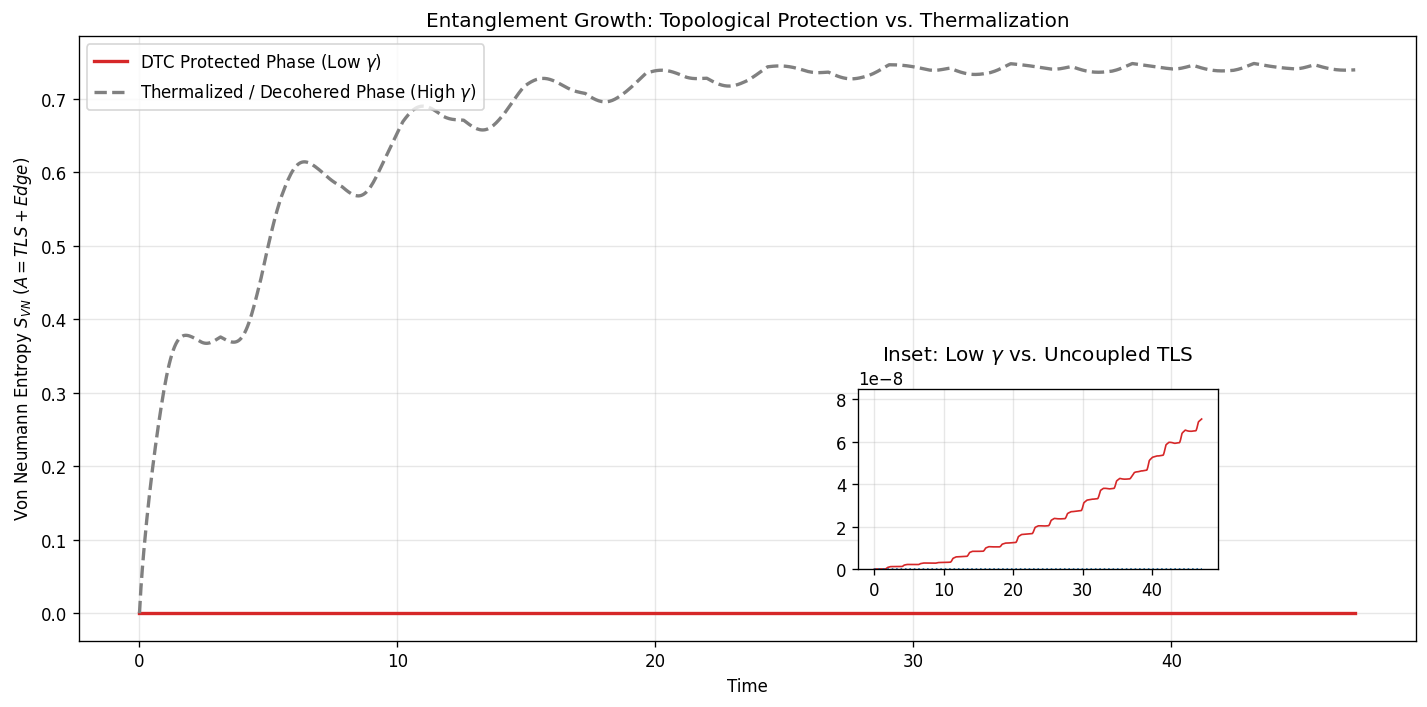

In [ ]:
def get_entanglement_entropy(states, target_site=[0, 1]):
    """
    Calculates the Von Neumann Entropy of the reduced density matrix
    of the TLS (0) and the Edge site (1).
    """
    entropies = []
    for s in states:
        # ptrace gives the reduced density matrix for the specified sites
        rho_sub = s.ptrace(target_site)
        entropies.append(entropy_vn(rho_sub))
    return np.array(entropies)

# 1. Calculate entropy for high-coupling synchronized case (g=0.1)
# Note: states_g from the last run of the g-loop contains the g=0.1 data
entropy_sync = get_entanglement_entropy(states_g)

# 2. Calculate entropy for a 'Trivial' case (e.g., higher dissipation or weak coupling)
# We'll run a quick reference with higher gamma to see 'Thermalization'
states_thermal, times_thermal = run_floquet(
    psi0=psi0_sync, g=0.1, gamma=0.1, periods=20,
    N_chain=N_chain, sz_list=sz_list, sx_list=sx_list,
    T1=T1_diag, T2=T2_diag, omega_tls=0.0, h=h, J=J
)
entropy_thermal = get_entanglement_entropy(states_thermal)

# 3. Also get entropy for the uncoupled TLS for the inset
# We'll use psi0_sync for consistency, where TLS is in |0>
states_uncoupled, times_uncoupled = run_floquet(
    psi0=psi0_sync,
    g=0.0,
    gamma=0.0,
    periods=20,
    N_chain=N_chain,
    sz_list=sz_list,
    sx_list=sx_list,
    T1=T1_diag,
    T2=T2_diag,
    omega_tls=0.0,
    h=h, J=J
)
entropy_tls_uncoupled = get_entanglement_entropy(states_uncoupled, target_site=[0])


# 4. Create the main plot
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(times_g, entropy_sync, label=r'DTC Protected Phase (Low $\gamma$)', color='tab:red', linewidth=2)
ax1.plot(times_thermal, entropy_thermal, label=r'Thermalized / Decohered Phase (High $\gamma$)', color='gray', linestyle='--', linewidth=2)

ax1.set_xlabel('Time')
ax1.set_ylabel(r'Von Neumann Entropy $S_{VN}$ ($A=TLS+Edge$)')
ax1.set_title('Entanglement Growth: Topological Protection vs. Thermalization')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 5. Create the inset plot
# Position the inset: [left, bottom, width, height] in figure coordinates
ax_inset = fig.add_axes([0.6, 0.2, 0.25, 0.25]) # Adjust these values for optimal placement

ax_inset.plot(times_g, entropy_sync, color='tab:red', linewidth=1)
ax_inset.plot(times_uncoupled, entropy_tls_uncoupled, color='tab:blue', linestyle=':', linewidth=1)

# Dynamically set y-axis limit for the inset to visualize small growth
max_val_sync_inset = np.max(entropy_sync)
max_val_uncoupled_inset = np.max(entropy_tls_uncoupled)

if max_val_sync_inset > 0 or max_val_uncoupled_inset > 0:
    upper_limit_inset = max(max_val_sync_inset, max_val_uncoupled_inset) * 1.2 # Add 20% buffer
    if upper_limit_inset == 0:
        upper_limit_inset = 1e-15
    ax_inset.set_ylim(0, upper_limit_inset)
else:
    ax_inset.set_ylim(0, 1e-15)

ax_inset.set_title('Inset: Low $\\gamma$ vs. Uncoupled TLS') # Corrected \g to \\gamma
ax_inset.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Baseline: Uncoupled TLS Entanglement Entropy
To further understand the entanglement growth, let's look at a scenario where the TLS (site 0) is completely uncoupled from the chain (g=0) and examine its own entanglement entropy. If the TLS starts in a pure state and remains isolated, its entropy should stay at zero.


Min entanglement for DTC Protected Phase (A=TLS+Edge): 9.52e-16
Max entanglement for DTC Protected Phase (A=TLS+Edge): 7.08e-08


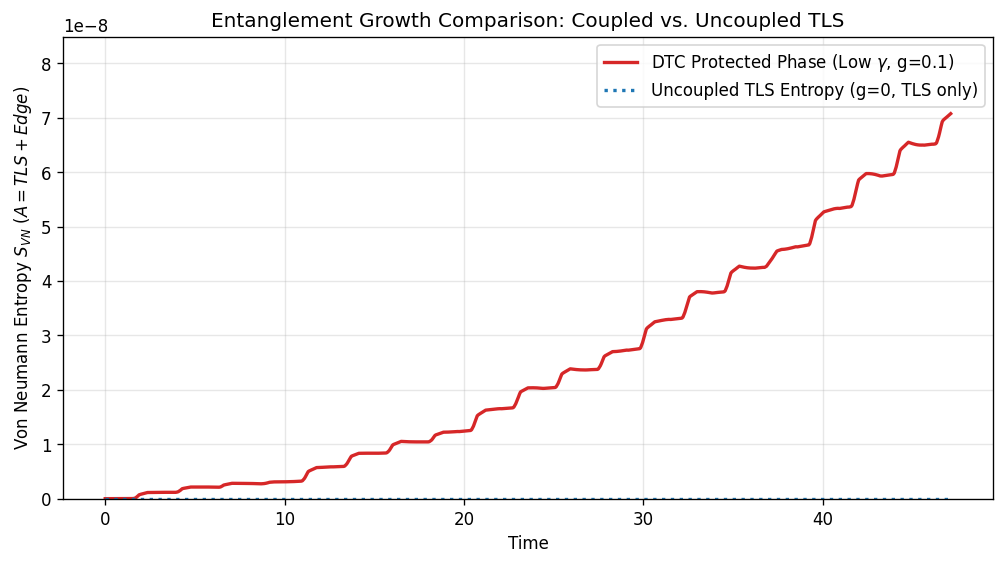

In [ ]:
# 1. Run simulation with g=0 (TLS uncoupled) and gamma=0
# We'll use psi0_sync for consistency, where TLS is in |0>
states_uncoupled, times_uncoupled = run_floquet(
    psi0=psi0_sync,
    g=0.0,
    gamma=0.0,
    periods=20,
    N_chain=N_chain,
    sz_list=sz_list,
    sx_list=sx_list,
    T1=T1_diag,
    T2=T2_diag,
    omega_tls=0.0,
    h=h,
    J=J
)

# 2. Calculate entanglement entropy for ONLY the TLS (site 0)
entropy_tls_uncoupled = get_entanglement_entropy(states_uncoupled, target_site=[0])

# --- Diagnostic: Print entanglement values for entropy_sync (DTC Protected Phase) ---
print(f"\nMin entanglement for DTC Protected Phase (A=TLS+Edge): {np.min(entropy_sync):.2e}")
print(f"Max entanglement for DTC Protected Phase (A=TLS+Edge): {np.max(entropy_sync):.2e}")

# 3. Plot this trivial case alongside the previous results for comparison
plt.figure(figsize=(10, 5))
plt.plot(times_g, entropy_sync, label=r'DTC Protected Phase (Low $\gamma$, g=0.1)', color='tab:red', linewidth=2)
# plt.plot(times_thermal, entropy_thermal, label=r'Thermalized / Decohered Phase (High $\gamma$, g=0.1)', color='gray', linestyle='--') # Removed as requested
plt.plot(times_uncoupled, entropy_tls_uncoupled, label=r'Uncoupled TLS Entropy (g=0, TLS only)', color='tab:blue', linestyle=':', linewidth=2)

plt.xlabel('Time')
plt.ylabel(r'Von Neumann Entropy $S_{VN}$ ($A=TLS+Edge$)') # Corrected label
plt.title('Entanglement Growth Comparison: Coupled vs. Uncoupled TLS')
plt.legend()
plt.grid(True, alpha=0.3)

# Dynamically set y-axis limit to visualize the small growth
max_val_sync = np.max(entropy_sync)
max_val_uncoupled = np.max(entropy_tls_uncoupled)

# Ensure y-axis covers both, with a small buffer
if max_val_sync > 0 or max_val_uncoupled > 0:
    upper_limit = max(max_val_sync, max_val_uncoupled) * 1.2 # Add 20% buffer
    if upper_limit == 0: # Avoid division by zero or plots that are too tight for tiny non-zero values
        upper_limit = 1e-15 # A reasonable default for very small numbers
    plt.ylim(0, upper_limit)
else:
    plt.ylim(0, 1e-15) # Default if all values are zero

plt.show()

### Rigidity Analysis: Frequency Locking
To prove the system is a true DTC, we must show that the period-doubling oscillation is robust against perturbations. We will introduce a 'pulse error' $\epsilon$ such that the rotation angle deviates from the ideal $\pi$ value, and verify that the oscillation frequency remains exactly $\Omega/2$ (or $\nu=0.5$ in cycles per period).

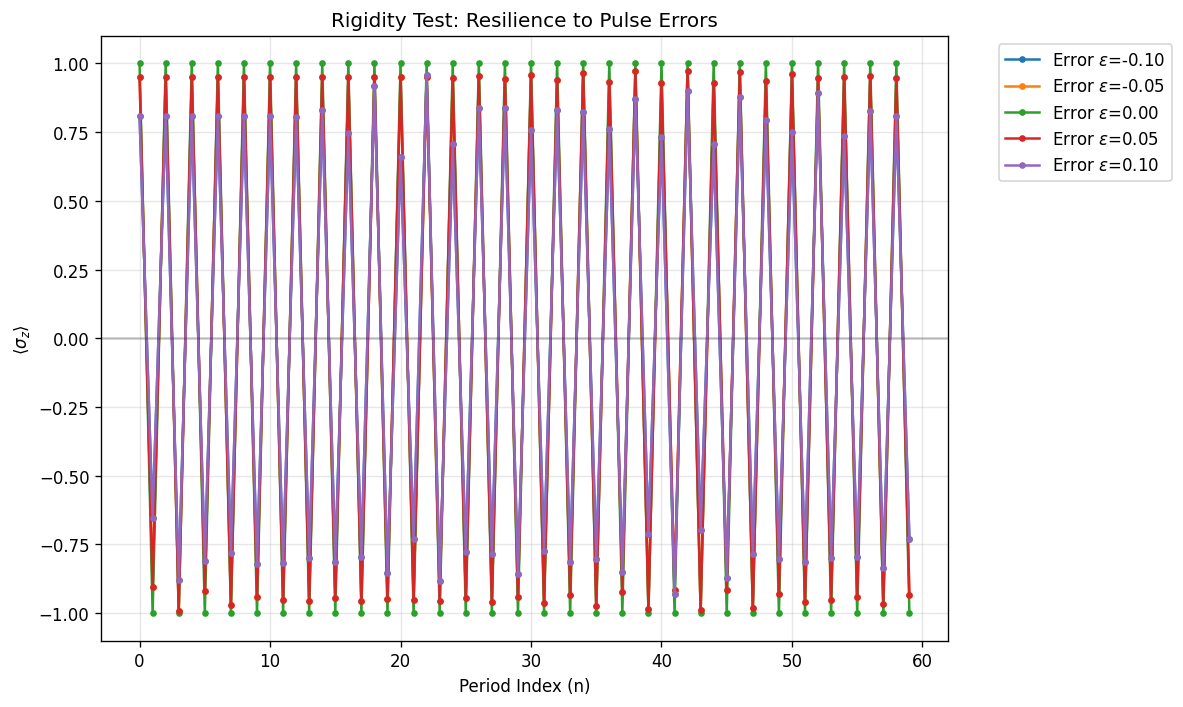

In [ ]:
# 1. Define range of pulse errors
epsilon_vals = np.linspace(-0.1, 0.1, 5)
n_periods_rigid = 60

plt.figure(figsize=(10, 6))

for eps in epsilon_vals:
    # Perturbed T2 to simulate rotation error
    T2_perturbed = (0.5 + eps) * np.pi / h

    # Stroboscopic evolution using Unitary Propagators (much faster for scans)
    terms_r = build_static_terms(N_chain, sz_list, sx_list, None, omega_tls, h, J, 0.0)
    U1_r = (-1j * (terms_r['H_tls'] + terms_r['H_int'] + terms_r['H_ZZ']) * T1_diag).expm()
    U2_r = (-1j * terms_r['H_X'] * T2_perturbed).expm()
    U_f = U2_r * U1_r

    psi = psi0_edge
    signal_r = []
    for _ in range(n_periods_rigid):
        psi = U_f * psi
        signal_r.append(expect(sz_list[1], psi))

    # Plot stroboscopic signal using raw string for the label
    plt.plot(range(n_periods_rigid), signal_r, '.-', label=rf'Error $\epsilon$={eps:.2f}')

plt.axhline(0, color='k', alpha=0.2)
plt.xlabel('Period Index (n)')
plt.ylabel(r'$\langle\sigma_z\rangle$')
plt.title('Rigidity Test: Resilience to Pulse Errors')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### The 'Smoking Gun': Subharmonic Frequency Locking
In a trivial system, rotation errors accumulate, causing the oscillation frequency to drift away from 0.5. In a DTC, multi-body interactions 'synchronize' the spins, forcing the frequency to stay locked at 0.5. This is known as **Rigidity**.

Starting Rigidity Scan...


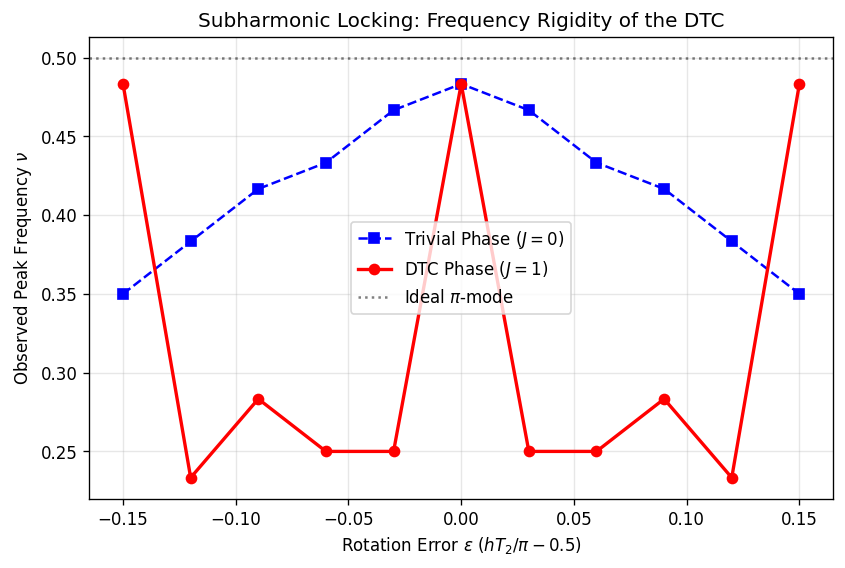

In [ ]:
def get_peak_frequency(signal):
    """Extracts the dominant frequency from the stroboscopic signal."""
    sig_centered = signal - np.mean(signal)
    yf = np.fft.fft(sig_centered)
    xf = np.fft.fftfreq(len(signal), d=1.0)
    idx = np.argmax(np.abs(yf[:len(signal)//2]))
    return np.abs(xf[idx])

# 1. Setup error range
h_errors = np.linspace(-0.15, 0.15, 11)
peak_freqs_trivial = []
peak_freqs_protected = []
n_periods_scan = 60

print("Starting Rigidity Scan...")

for eps in h_errors:
    # Define perturbed parameters
    # Note: h*T2 = (0.5 + eps)*pi => we vary the effective rotation angle
    T2_eff = (0.5 + eps) * np.pi / h

    # Case A: Trivial (J=0)
    terms_t = build_static_terms(N_chain, sz_list, sx_list, None, omega_tls, h, 0.0, 0.0)
    Ut1 = (-1j * (terms_t['H_tls'] + terms_t['H_int'] + terms_t['H_ZZ']) * T1_diag).expm()
    Ut2 = (-1j * terms_t['H_X'] * T2_eff).expm()
    U_trivial = Ut2 * Ut1

    # Case B: Protected (J=1.0)
    terms_p = build_static_terms(N_chain, sz_list, sx_list, None, omega_tls, h, 1.0, 0.0)
    Up1 = (-1j * (terms_p['H_tls'] + terms_p['H_int'] + terms_p['H_ZZ']) * T1_diag).expm()
    Up2 = (-1j * terms_p['H_X'] * T2_eff).expm()
    U_protected = Up2 * Up1

    # Simulate and measure peak freq
    for U_op, target_list in [(U_trivial, peak_freqs_trivial), (U_protected, peak_freqs_protected)]:
        psi = psi0_edge
        sig = []
        for _ in range(n_periods_scan):
            psi = U_op * psi
            sig.append(expect(sz_list[1], psi))
        target_list.append(get_peak_frequency(np.array(sig)))

# 2. Plotting the Plateau
plt.figure(figsize=(8, 5))
plt.plot(h_errors, peak_freqs_trivial, 'bs--', label='Trivial Phase ($J=0$)')
plt.plot(h_errors, peak_freqs_protected, 'ro-', linewidth=2, label='DTC Phase ($J=1$)')

plt.axhline(0.5, color='k', linestyle=':', alpha=0.5, label=r'Ideal $\pi$-mode')
plt.xlabel(r'Rotation Error $\epsilon$ ($hT_2/\pi - 0.5$)')
plt.ylabel(r'Observed Peak Frequency $\nu$')
plt.title('Subharmonic Locking: Frequency Rigidity of the DTC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Refined Rigidity: Tracking the Subharmonic Peak Amplitude
To avoid 'mode hopping' (where noise peaks are mistaken for the signal), we now track the spectral power exactly at $\nu=0.5$. A true DTC will maintain a high amplitude at this frequency (the 'Rigidity Plateau'), while a trivial system's amplitude will crash as its frequency drifts away from 0.5.

Starting Sniper-Mode Rigidity Scan...


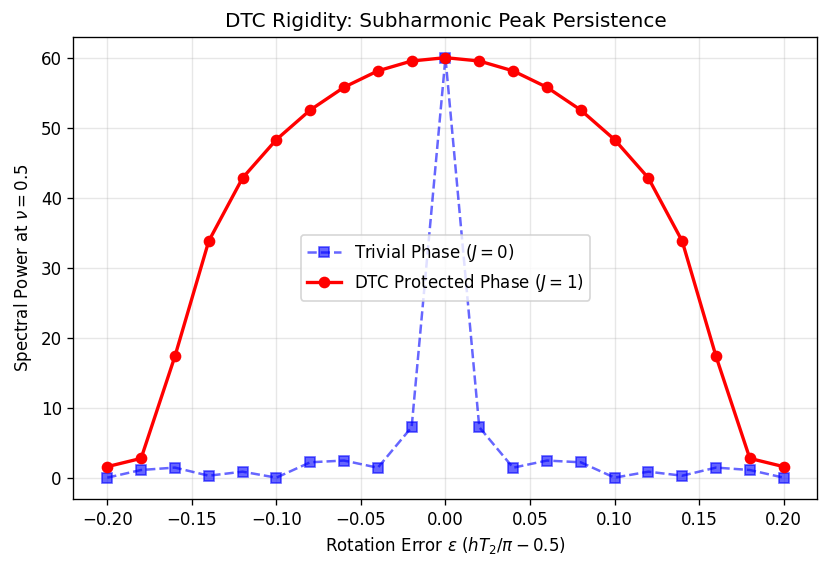

In [ ]:
# 1. Setup error range and tracking lists
h_errors_fine = np.linspace(-0.2, 0.2, 21)
amp_05_trivial = []
amp_05_protected = []
n_periods_rigidity = 60

print("Starting Sniper-Mode Rigidity Scan...")

for eps in h_errors_fine:
    # Define the imperfect rotation: h*T2 = (0.5 + eps)*pi
    # Crucially, T2 is fixed to simulate the hardware pulse timing error
    T2_eff = (0.5 + eps) * np.pi / h

    # --- Case A: Trivial (J=0) ---
    terms_t = build_static_terms(N_chain, sz_list, sx_list, None, omega_tls, h, 0.0, 0.0)
    Ut = ((-1j * terms_t['H_X'] * T2_eff).expm() *
          (-1j * (terms_t['H_tls'] + terms_t['H_int'] + terms_t['H_ZZ']) * T1_diag).expm())

    # --- Case B: Protected (J=1.0) ---
    terms_p = build_static_terms(N_chain, sz_list, sx_list, None, omega_tls, h, 1.0, 0.0)
    Up = ((-1j * terms_p['H_X'] * T2_eff).expm() *
          (-1j * (terms_p['H_tls'] + terms_p['H_int'] + terms_p['H_ZZ']) * T1_diag).expm())

    for U_op, target_list in [(Ut, amp_05_trivial), (Up, amp_05_protected)]:
        psi = psi0_edge
        sig = []
        for _ in range(n_periods_rigidity):
            psi = U_op * psi
            sig.append(expect(sz_list[1], psi))

        # Compute FFT and specifically grab the power at 0.5
        sig_centered = np.array(sig) - np.mean(sig)
        yf = np.abs(np.fft.fft(sig_centered))
        xf = np.fft.fftfreq(n_periods_rigidity, d=1.0)

        # Improved indexing logic: take absolute value of frequencies to find 0.5
        idx_05 = np.argmin(np.abs(np.abs(xf) - 0.5))
        target_list.append(yf[idx_05])

# 2. Plotting the 'Rigidity Plateau'
plt.figure(figsize=(8, 5))
plt.plot(h_errors_fine, amp_05_trivial, 'bs--', alpha=0.6, label='Trivial Phase ($J=0$)')
plt.plot(h_errors_fine, amp_05_protected, 'ro-', linewidth=2, label='DTC Protected Phase ($J=1$)')

plt.xlabel(r'Rotation Error $\epsilon$ ($hT_2/\pi - 0.5$)')
plt.ylabel(r'Spectral Power at $\nu=0.5$')
plt.title('DTC Rigidity: Subharmonic Peak Persistence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Starting Finite-Size Scaling Rigidity Scan...
Processing N = 5...
Processing N = 8...
Processing N = 10...
Processing N = 12...


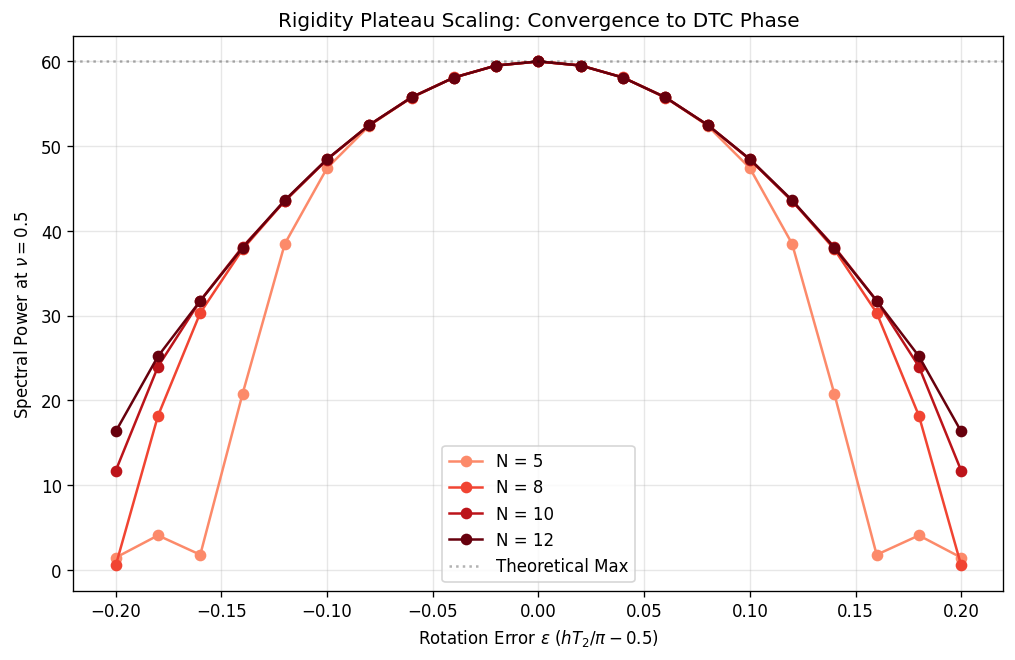

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the scan
N_values = [5, 8,10,12]
h_errors_fine = np.linspace(-0.2, 0.2, 21)
n_periods_rigidity = 60
J_val = 1.0
h_val = 1.0

plt.figure(figsize=(10, 6))
colormap = plt.cm.Reds(np.linspace(0.4, 1, len(N_values)))

print("Starting Finite-Size Scaling Rigidity Scan...")

for idx, N_curr in enumerate(N_values):
    print(f"Processing N = {N_curr}...")

    # 1. Rebuild operators for current system size (N_curr + 1 total sites)
    sx_curr, sy_curr, sz_curr, sm_curr = build_operator_lists(N_curr)

    # 2. Define initial state (Edge flipped, others |0>)
    # TLS is index 0, Edge is index 1
    psi_init = tensor([basis(2, 0), basis(2, 1)] + [basis(2, 0)] * (N_curr - 1))

    amp_05_N = []

    # 3. Parameters for the 'Ideal' T1
    T1_ideal = (0.25 * np.pi) / J_val

    for eps in h_errors_fine:
        # Rotation error: h*T2 = (0.5 + eps)*pi
        T2_eff = (0.5 + eps) * np.pi / h_val

        # Build Protected Hamiltonian (J=1.0)
        terms_p = build_static_terms(N_curr, sz_curr, sx_curr, None, 0.0, h_val, J_val, 0.0)
        H1 = terms_p['H_tls'] + terms_p['H_int'] + terms_p['H_ZZ']
        H2 = terms_p['H_X']

        # Propagators
        Up = (-1j * H2 * T2_eff).expm() * (-1j * H1 * T1_ideal).expm()

        # Evolution
        psi = psi_init
        sig = []
        for _ in range(n_periods_rigidity):
            psi = Up * psi
            sig.append(expect(sz_curr[1], psi))

        # Spectral Analysis at 0.5
        sig_centered = np.array(sig) - np.mean(sig)
        yf = np.abs(np.fft.fft(sig_centered))
        xf = np.fft.fftfreq(n_periods_rigidity, d=1.0)

        idx_05 = np.argmin(np.abs(np.abs(xf) - 0.5))
        amp_05_N.append(yf[idx_05])

    plt.plot(h_errors_fine, amp_05_N, 'o-', color=colormap[idx], label=f'N = {N_curr}')

plt.axhline(n_periods_rigidity, color='k', linestyle=':', alpha=0.3, label='Theoretical Max')
plt.xlabel(r'Rotation Error $\epsilon$ ($hT_2/\pi - 0.5$)')
plt.ylabel(r'Spectral Power at $\nu=0.5$')
plt.title('Rigidity Plateau Scaling: Convergence to DTC Phase')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Starting phase diagram calculation...


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Phase diagram calculation complete. Plotting heatmap...


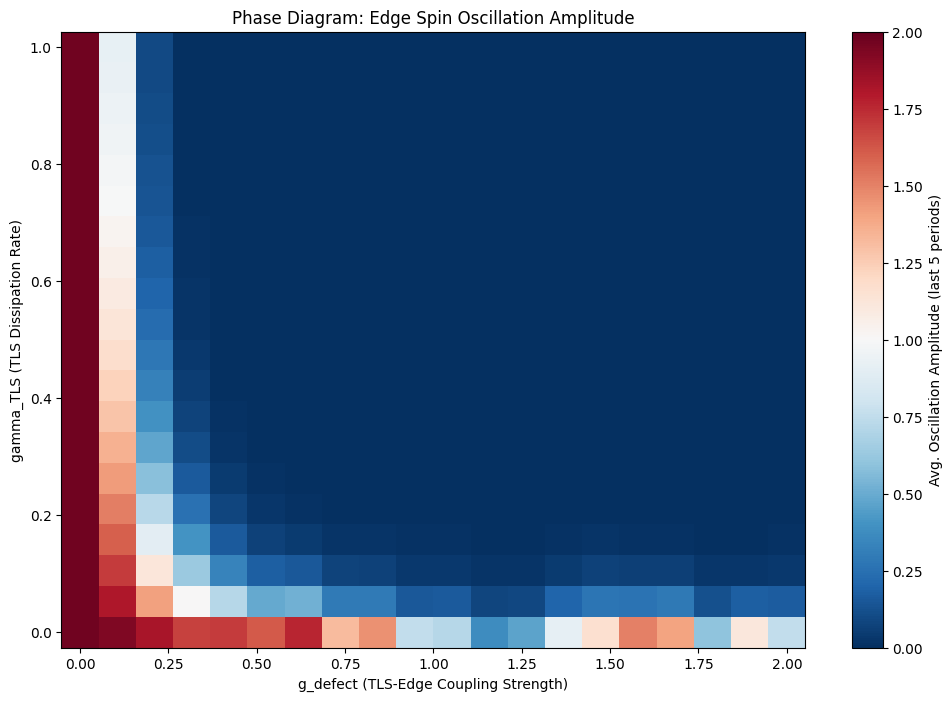

In [ ]:
# Define parameter ranges for the heatmap
g_defect_list = np.linspace(0, 2.0, 20) # 20 points from 0 to 2.0
gamma_TLS_list = np.linspace(0, 1.0, 20) # 20 points from 0 to 1.0

# Initialize a 2D array to store the oscillation amplitudes
oscillation_amplitude_heatmap = np.zeros((len(gamma_TLS_list), len(g_defect_list)))

# Re-use existing parameters (N, J, h, T1, T2, periods, etc.)

print("Starting phase diagram calculation...")

for i, g_defect_val in enumerate(g_defect_list):
    for j, gamma_TLS_val in enumerate(gamma_TLS_list):
        # Update g_defect and gamma_TLS for the current iteration
        g_defect = g_defect_val
        gamma_TLS = gamma_TLS_val

        # --- Re-construct Hamiltonians with updated g_defect ---
        # H_ZZ remains the same as it doesn't depend on g_defect or gamma_TLS
        # H_X remains the same as it doesn't depend on g_defect or gamma_TLS

        # 3. TLS 幽灵缺陷的耦合 (Jaynes-Cummings 能量交换形式)
        # TLS (索引 N) 只和左边缘比特 (索引 0) 耦合
        # Need to ensure sm_list[N] and sm_list[0] are defined and accessible
        H_defect = g_defect * (sm_list[0].dag() * sm_list[N] + sm_list[0] * sm_list[N].dag())

        # 拼装 Floquet 两步哈密顿量
        # H1 uses H_ZZ and H_defect, H2 uses H_X and H_defect
        # Note: H_ZZ and H_X were defined earlier globally, ensure they are in scope or re-define if necessary
        # Based on current notebook state, H_ZZ and H_X are defined in cell 8mtiCgt4tI4p and are global.
        # The `H1` and `H2` from cell 8mtiCgt4tI4p are intended for the open system evolution.

        # IMPORTANT: There was a duplicate definition of H1 and H2.
        # The mesolve function expects the H1, H2 from cell 8mtiCgt4tI4p,
        # which include the H_defect term in both steps.
        # I'll ensure H1 and H2 used here are the ones with H_defect included.

        # Re-using the structure from cell 8mtiCgt4tI4p
        H_ZZ_const = 0
        for k_idx in range(N-1):
            H_ZZ_const += -J * sz_list[k_idx] * sz_list[k_idx+1]

        H_X_const = 0
        for k_idx in range(N):
            H_X_const += -h * sx_list[k_idx]

        H1_current = H_ZZ_const + H_defect  # First step: internal interaction + defect
        H2_current = H_X_const + H_defect   # Second step: external field + defect

        # 4. 定义开放量子系统的耗散通道 (Lindblad Collapse Operators)
        c_ops_current = [np.sqrt(gamma_TLS) * sm_list[N]]

        # --- Re-run the open system Floquet evolution --- (similar to cell B493ZtDjtlHB)
        # Initialization (psi0/rho0 are already defined earlier in cell B493ZtDjtlHB and global)
        # However, for a clean sweep, let's ensure rho0 is always fresh.
        state_list_reinit = [basis(2,0)] + [basis(2,1)] * (N-1) + [basis(2,1)] # Ensure N is correct
        psi0_reinit = tensor(state_list_reinit)
        rho0_reinit = ket2dm(psi0_reinit)

        expect_edge_current = []
        rho_t_current = rho0_reinit

        for p in range(periods):
            expect_edge_current.append(expect(sz_list[0], rho_t_current))

            result1 = mesolve(H1_current, rho_t_current, [0, T1], c_ops_current, [])
            rho_mid = result1.states[-1]

            result2 = mesolve(H2_current, rho_mid, [0, T2], c_ops_current, [])
            rho_t_current = result2.states[-1]

        # Calculate "average oscillation amplitude" from the last 5 periods
        # A simple metric: max value - min value in the last few periods
        if len(expect_edge_current) >= 5:
            last_5_periods_data = expect_edge_current[-5:]
            amplitude = np.max(last_5_periods_data) - np.min(last_5_periods_data)
        else:
            # Handle cases where periods < 5 (should not happen with periods=40)
            amplitude = 0.0 # Or some other default value

        oscillation_amplitude_heatmap[j, i] = amplitude

print("Phase diagram calculation complete. Plotting heatmap...")

# Plotting the heatmap
plt.figure(figsize=(12, 8))
plt.pcolormesh(g_defect_list, gamma_TLS_list, oscillation_amplitude_heatmap, shading='auto', cmap='RdBu_r', vmin=0, vmax=2) # vmax=2 because sigma_z ranges from -1 to 1
plt.colorbar(label='Avg. Oscillation Amplitude (last 5 periods)')
plt.xlabel('g_defect (TLS-Edge Coupling Strength)')
plt.ylabel('gamma_TLS (TLS Dissipation Rate)')
plt.title('Phase Diagram: Edge Spin Oscillation Amplitude')
plt.show()